# A Theoretical Note on Inflation-Indexed Securities Valuation
## TIPS and BTP€i Mechanics, Adjustments, and Real Returns

### 1. The Fundamental Premise of Real Yields
In standard fixed-income pricing, conventional bonds expose the investor to **inflation risk**—the erosion of purchasing power over the life of the asset. The nominal yield of a standard bond encapsulates both a demanded real return and a premium for expected inflation. This relationship is classically defined by the Fisher Equation:

$$(1 + r_{nom}) = (1 + r_{real})(1 + \pi^e)$$

Where:
* $r_{nom}$ is the nominal interest rate.
* $r_{real}$ is the real interest rate.
* $\pi^e$ is the expected inflation rate.

To immunize portfolios against inflation volatility, sovereign treasuries issue inflation-indexed securities, most notably Treasury Inflation-Protected Securities (TIPS) in the United States and BTP€is in Europe. Unlike nominal bonds, these securities guarantee a specified *real* rate of return.

### 2. Mechanics of Principal Adjustment (TIPS Model)
The definitive structural feature of TIPS is that the **coupon rate remains fixed**, but the **principal balance is dynamically adjusted** in tandem with a realized inflation index—specifically, the non-seasonally adjusted Consumer Price Index for All Urban Consumers (CPI-U).

The adjustment mechanism is governed by the **Index Ratio ($IR$)**. The Index Ratio quantifies the cumulative inflation (or deflation) from the bond's issuance (or base date) to the current settlement date.

$$IR_t = \frac{CPI_t}{CPI_{Base}}$$

The **Adjusted Principal ($P_t$)** is then calculated by scaling the original face value by the Index Ratio:

$$P_t = P_0 \times IR_t$$

*(Note: In the event of persistent deflation where $IR_t < 1.0$, the U.S. Treasury embeds a deflation floor at maturity, guaranteeing the investor will receive the greater of the Adjusted Principal or the Original Principal $P_0$.)*

#### Adjusted Coupon Payments and Total Return
Because the semi-annual coupon payments are calculated as a fixed percentage of the *adjusted* principal, the actual cash flows rise with inflation.

$$C_t = P_t \times \frac{c}{2} = (P_0 \times IR_t) \times \frac{c}{2}$$

The **Real Rate of Return** over a holding period strips out the inflation component. Deflating the cash flows back by the index ratio yields the original fixed coupon rate, perfectly isolating the investor's real purchasing power.

### 3. The European Case Study: BTP€i Valuation and Interpolation

In the sovereign debt markets of the Eurozone, the Italian Treasury issues **BTP€i** (Buoni del Tesoro Poliennali Indicizzati all'Inflazione Europea). While the core philosophy is identical to TIPS, the mechanical execution requires precise mathematical treatment due to index reporting lags.

#### The Reference Index and Lag Interpolation
BTP€i bonds are indexed to the Harmonized Index of Consumer Prices (HICP) excluding tobacco. Due to publication delays, the settlement utilizes a lagged index. For a specific settlement day $d$ in month $m$, the **Reference CPI** ($CPI_{Ref, d}$) is calculated via linear interpolation between the CPI of three months prior ($m-3$) and two months prior ($m-2$):

$$CPI_{Ref, d} = CPI_{m-3} + \frac{d - 1}{D} \times (CPI_{m-2} - CPI_{m-3})$$

Where $d$ is the settlement day, and $D$ is the total days in the settlement month.

The equivalent of the TIPS Index Ratio is the **Indexation Coefficient ($CI$)**, mathematically defined as:

$$CI_d = \frac{CPI_{Ref, d}}{CPI_{Base}}$$

### 4. Computational Implementation in Python
The following cells encapsulate the valuation frameworks for both TIPS and BTP€i into an object-oriented paradigm, concluding with a historical simulation of principal revaluation.

In [3]:
class TIPSPricer:
    def __init__(self, original_principal: float, annual_coupon_rate: float, base_cpi: float):
        self.P0 = original_principal
        self.c = annual_coupon_rate
        self.base_cpi = base_cpi

    def calculate_index_ratio(self, current_cpi: float) -> float:
        return current_cpi / self.base_cpi

    def get_adjusted_principal(self, current_cpi: float) -> float:
        ir = self.calculate_index_ratio(current_cpi)
        return self.P0 * ir

    def calculate_semi_annual_coupon(self, current_cpi: float) -> float:
        p_adj = self.get_adjusted_principal(current_cpi)
        return p_adj * (self.c / 2.0)

    @staticmethod
    def calculate_real_return(nominal_cash_flow: float, initial_investment: float, index_ratio: float) -> float:
        real_cash_flow = nominal_cash_flow / index_ratio
        return (real_cash_flow - initial_investment) / initial_investment

# --- Execution: TIPS Valuation ---
face_value = 1000.0
fixed_coupon = 0.025
cpi_issue = 250.000
tips = TIPSPricer(face_value, fixed_coupon, cpi_issue)

cpi_current = 257.500  # Assumed inflation
ir = tips.calculate_index_ratio(cpi_current)
adj_principal = tips.get_adjusted_principal(cpi_current)
coupon_payment = tips.calculate_semi_annual_coupon(cpi_current)

print(f"--- TIPS Valuation Mechanics ---")
print(f"Index Ratio (IR)      : {ir:.4f}")
print(f"Adjusted Principal    : ${adj_principal:,.2f}")
print(f"Semi-Annual Coupon    : ${coupon_payment:,.2f} (vs ${face_value * fixed_coupon / 2:.2f} unadjusted)")

--- TIPS Valuation Mechanics ---
Index Ratio (IR)      : 1.0300
Adjusted Principal    : $1,030.00
Semi-Annual Coupon    : $12.88 (vs $12.50 unadjusted)


In [4]:
class BTPiPricer:
    def __init__(self, notional: float, annual_coupon: float, base_cpi: float):
        self.notional = notional
        self.coupon_rate = annual_coupon
        self.base_cpi = base_cpi

    @staticmethod
    def calculate_reference_cpi(cpi_m3: float, cpi_m2: float, day_d: int, days_in_month_D: int) -> float:
        interpolation_factor = (day_d - 1) / days_in_month_D
        return cpi_m3 + interpolation_factor * (cpi_m2 - cpi_m3)

    def calculate_indexation_coefficient(self, ref_cpi: float) -> float:
        return round(ref_cpi / self.base_cpi, 6)

# --- Execution: BTP€i Valuation ---
btpi = BTPiPricer(100000.0, 0.015, 118.250)

ref_cpi = BTPiPricer.calculate_reference_cpi(121.100, 121.450, 15, 30)
ci = btpi.calculate_indexation_coefficient(ref_cpi)
adj_principal = 100000.0 * ci

print(f"\n--- BTP€i Valuation Case Study ---")
print(f"Interpolated Ref CPI  : {ref_cpi:.5f}")
print(f"Indexation Coeff (CI) : {ci:.6f}")
print(f"Adjusted Principal    : €{adj_principal:,.2f}")


--- BTP€i Valuation Case Study ---
Interpolated Ref CPI  : 121.26333
Indexation Coeff (CI) : 1.025483
Adjusted Principal    : €102,548.30


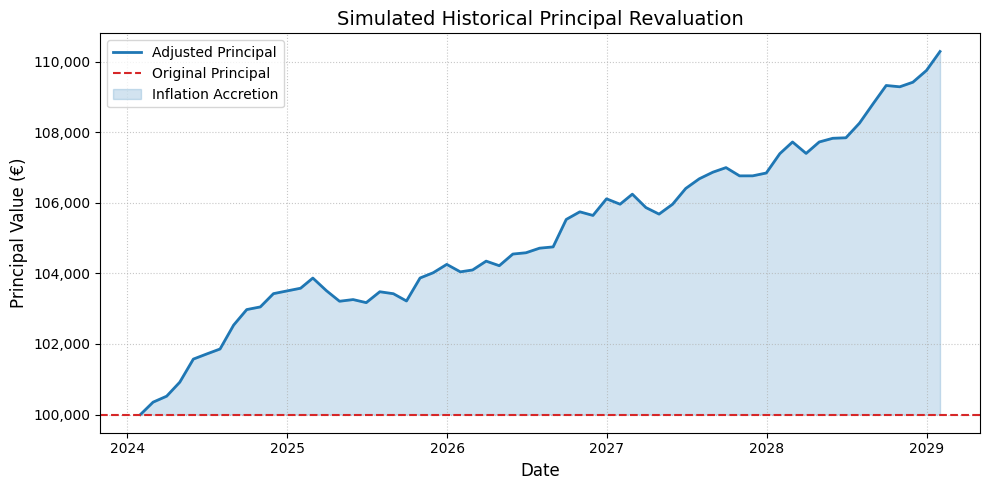

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Execution: Historical Revaluation Simulation ---
np.random.seed(42)
months = 60
base_cpi = 118.25
notional = 100000.0

# Simulating a 2.5% annualized inflation with some volatility
monthly_drift = 0.025 / 12
inflation_shocks = np.random.normal(monthly_drift, 0.01 / np.sqrt(12), months)

cpi_values = [base_cpi]
for shock in inflation_shocks:
    cpi_values.append(cpi_values[-1] * (1 + shock))

dates = pd.date_range(start="2024-01-01", periods=months + 1, freq="ME")
df = pd.DataFrame({'Date': dates, 'HICP_Index': cpi_values})
df['Indexation_Coefficient'] = df['HICP_Index'] / base_cpi
df['Adjusted_Principal'] = notional * df['Indexation_Coefficient']

plt.figure(figsize=(10, 5))
plt.plot(df['Date'], df['Adjusted_Principal'], label='Adjusted Principal', color='#1f77b4', linewidth=2)
plt.axhline(y=notional, color='#d62728', linestyle='--', label='Original Principal')
plt.fill_between(df['Date'], notional, df['Adjusted_Principal'], color='#1f77b4', alpha=0.2, label='Inflation Accretion')

plt.title('Simulated Historical Principal Revaluation', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Principal Value (€)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='upper left')

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.tight_layout()
plt.show()
